# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings 
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import time
from sklearn.metrics import confusion_matrix, classification_report
from sklearn import metrics
import pickle

In [2]:
import fuzzywuzzy
from fuzzywuzzy import process

# Importing Dataset

In [3]:
df=pd.read_csv('drug_deaths.csv',index_col='Unnamed: 0')

# EDA

In [4]:
df.head()

,ID,Date,DateType,Age,Sex,Race,ResidenceCity,ResidenceCounty,ResidenceState,DeathCity,...,Tramad,Morphine_NotHeroin,Hydromorphone,Other,OpiateNOS,AnyOpioid,MannerofDeath,DeathCityGeo,ResidenceCityGeo,InjuryCityGeo
0,14-0273,06/28/2014 12:00:00 AM,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,NaN,0,0,Accident,"CT\n(41.575155, -72.738288)","CT\n(41.575155, -72.738288)","CT\n(41.575155, -72.738288)"
1,13-0102,03/21/2013 12:00:00 AM,0.0,48.0,Male,Black,NORWALK,NaN,NaN,NORWALK,...,0,0,0,NaN,0,0,Accident,"Norwalk, CT\n(41.11805, -73.412906)","NORWALK, CT\n(41.11805, -73.412906)","CT\n(41.575155, -72.738288)"
2,16-0165,03/13/2016 12:00:00 AM,0.0,30.0,Female,White,SANDY HOOK,FAIRFIELD,CT,DANBURY,...,0,0,0,NaN,0,1,Accident,"Danbury, CT\n(41.393666, -73.451539)","SANDY HOOK, CT\n(41.419998, -73.282501)",NaN
3,16-0208,03/31/2016 12:00:00 AM,0.0,23.0,Male,White,RYE,WESTCHESTER,NY,GREENWICH,...,0,0,0,NaN,0,1,Accident,"Greenwich, CT\n(41.026526, -73.628549)",NaN,NaN
4,13-0052,02/13/2013 12:00:00 AM,0.0,22.0,Male,"Asian, Other",FLUSHING,QUEENS,NaN,GREENWICH,...,0,0,0,NaN,0,0,Accident,"Greenwich, CT\n(41.026526, -73.628549)",NaN,"CT\n(41.575155, -72.738288)"


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5105 entries, 0 to 5104
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   5105 non-null   object 
 1   Date                 5103 non-null   object 
 2   DateType             5103 non-null   float64
 3   Age                  5102 non-null   float64
 4   Sex                  5099 non-null   object 
 5   Race                 5092 non-null   object 
 6   ResidenceCity        4932 non-null   object 
 7   ResidenceCounty      4308 non-null   object 
 8   ResidenceState       3556 non-null   object 
 9   DeathCity            5100 non-null   object 
 10  DeathCounty          4005 non-null   object 
 11  Location             5081 non-null   object 
 12  LocationifOther      590 non-null    object 
 13  DescriptionofInjury  4325 non-null   object 
 14  InjuryPlace          5039 non-null   object 
 15  InjuryCity           3349 non-null   o

In [6]:
df.isnull().sum()

ID                        0
Date                      2
DateType                  2
Age                       3
Sex                       6
Race                     13
ResidenceCity           173
ResidenceCounty         797
ResidenceState         1549
DeathCity                 5
DeathCounty            1100
Location                 24
LocationifOther        4515
DescriptionofInjury     780
InjuryPlace              66
InjuryCity             1756
InjuryCounty           2741
InjuryState            3681
COD                       0
OtherSignifican        4936
Heroin                    0
Cocaine                   0
Fentanyl                  0
Fentanyl_Analogue         0
Oxycodone                 0
Oxymorphone               0
Ethanol                   0
Hydrocodone               0
Benzodiazepine            0
Methadone                 0
Amphet                    0
Tramad                    0
Morphine_NotHeroin        0
Hydromorphone             0
Other                  4670
OpiateNOS           

In [7]:
df.describe()

,DateType,Age,Heroin,Cocaine,Fentanyl_Analogue,Oxycodone,Oxymorphone,Ethanol,Hydrocodone,Benzodiazepine,Methadone,Amphet,Tramad,Hydromorphone,OpiateNOS
count,5103.000000,5102.000000,5105.000000,5105.000000,5105.000000,5105.000000,5105.000000,5105.000000,5105.000000,5105.000000,5105.000000,5105.000000,5105.000000,5105.000000,5105.000000
mean,0.446992,41.964916,0.495397,0.297943,0.076200,0.118903,0.021156,0.244270,0.023115,0.263075,0.092850,0.031146,0.025465,0.004897,0.017238
std,0.497231,12.336639,0.500028,0.457399,0.265344,0.323706,0.143917,0.429696,0.150282,0.440346,0.290251,0.173729,0.157549,0.069815,0.130170
min,0.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,52.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,87.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Data visualization

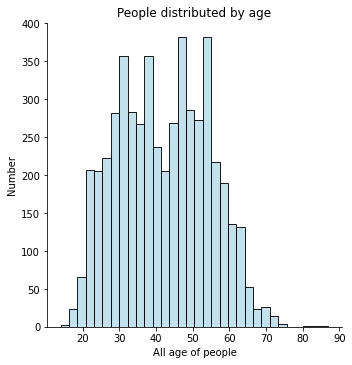

In [8]:
g = sns.displot(data=df, x='Age', kind='hist',color='lightblue', aspect=1, legend=False)
for ax in g.axes.flat:
    ax.set(title='People distributed by age',
          xlabel='All age of people',
           ylabel='Number')
plt.show()

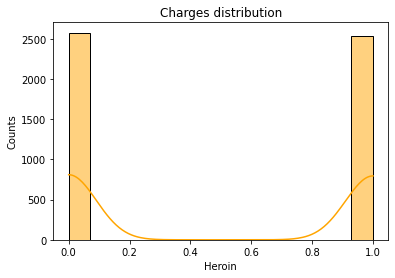

In [9]:
ax = sns.histplot(data=df, x='Heroin', kde=True, color='orange')
ax.set(title='Charges distribution', 
       xlabel='Heroin', 
       ylabel='Counts')
       
plt.show()

# Feature Selection

In [10]:
data = df.drop(['ID','Date','DateType','Race','Fentanyl','DescriptionofInjury','ResidenceCity','ResidenceCounty','ResidenceState','DeathCity','DeathCounty','Location','LocationifOther','InjuryPlace','InjuryCity','InjuryCounty','InjuryState','COD','OtherSignifican','Other','OpiateNOS','AnyOpioid','MannerofDeath','DeathCityGeo','ResidenceCityGeo','InjuryCityGeo', 'Morphine_NotHeroin'], axis =1)

# Data Cleaning

In [11]:
data.isnull().sum()

Age                  3
Sex                  6
Heroin               0
Cocaine              0
Fentanyl_Analogue    0
Oxycodone            0
Oxymorphone          0
Ethanol              0
Hydrocodone          0
Benzodiazepine       0
Methadone            0
Amphet               0
Tramad               0
Hydromorphone        0
dtype: int64

In [12]:
sex = {'Male': 1, 'Female': 0, 'Unidentified' : 2}


data['Sex'] = data['Sex'].map(sex)

In [13]:
data = data.dropna()

# DBSCAN

In [14]:
X = data.values


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=0.5, min_samples=5)


cluster_labels = dbscan.fit_predict(X_scaled)


if len(set(cluster_labels)) > 2:
    cluster_labels[cluster_labels != -1] = 0
    cluster_labels[cluster_labels == -1] = 1


data['Cluster'] = cluster_labels

print(data['Cluster'].value_counts())

0    4337
1     761
Name: Cluster, dtype: int64


# Model Building

In [15]:
X = data.drop(['Cluster'], axis =1)
y = data.Cluster

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [17]:
def evaluate(model, X_train, X_test, y_train, y_test):
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    print("TRAINIG RESULTS: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_train, y_train_pred, output_dict=True))
    print(f"CONFUSION MATRIX:\n{confusion_matrix(y_train, y_train_pred)}")
    print(f"ACCURACY SCORE:\n{accuracy_score(y_train, y_train_pred):.4f}")
    print(f"CLASSIFICATION REPORT:\n{clf_report}")

    print("TESTING RESULTS: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_test, y_test_pred, output_dict=True))
    print(f"CONFUSION MATRIX:\n{confusion_matrix(y_test, y_test_pred)}")
    print(f"ACCURACY SCORE:\n{accuracy_score(y_test, y_test_pred):.4f}")
    print(f"CLASSIFICATION REPORT:\n{clf_report}")

# Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression(random_state=0)
start_time = time.time()
LR.fit(X_train, y_train)
end_time = time.time()
lr_time = end_time - start_time

In [19]:
evaluate(LR, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[3374   82]
 [ 182  440]]
ACCURACY SCORE:
0.9353
CLASSIFICATION REPORT:
                     0           1  accuracy    macro avg  weighted avg
precision     0.948819    0.842912  0.935262     0.895865      0.932665
recall        0.976273    0.707395  0.935262     0.841834      0.935262
f1-score      0.962350    0.769231  0.935262     0.865791      0.932895
support    3456.000000  622.000000  0.935262  4078.000000   4078.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[859  22]
 [ 43  96]]
ACCURACY SCORE:
0.9363
CLASSIFICATION REPORT:
                    0           1  accuracy    macro avg  weighted avg
precision    0.952328    0.813559  0.936275     0.882944      0.933418
recall       0.975028    0.690647  0.936275     0.832838      0.936275
f1-score     0.963545    0.747082  0.936275     0.855313      0.934046
support    881.000000  139.000000  0.936275  1020.000000   1020.000000


In [20]:
y_pred = LR.predict(X_test)
a = accuracy_score(y_test, y_pred) * 100
p = precision_score(y_test,y_pred,average='macro') * 100 
r = recall_score(y_test,y_pred,average='macro') * 100
f = f1_score(y_test,y_pred,average='macro') * 100

# Decision Tree

In [21]:
from sklearn import tree

dt = tree.DecisionTreeClassifier()
start_time = time.time()  
dt.fit(X_train, y_train)
end_time = time.time()  

dt_time = end_time - start_time

In [22]:
evaluate(dt, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[3456    0]
 [   0  622]]
ACCURACY SCORE:
1.0000
CLASSIFICATION REPORT:
                0      1  accuracy  macro avg  weighted avg
precision     1.0    1.0       1.0        1.0           1.0
recall        1.0    1.0       1.0        1.0           1.0
f1-score      1.0    1.0       1.0        1.0           1.0
support    3456.0  622.0       1.0     4078.0        4078.0
TESTING RESULTS: 
CONFUSION MATRIX:
[[874   7]
 [ 19 120]]
ACCURACY SCORE:
0.9745
CLASSIFICATION REPORT:
                    0           1  accuracy    macro avg  weighted avg
precision    0.978723    0.944882   0.97451     0.961803      0.974112
recall       0.992054    0.863309   0.97451     0.927682      0.974510
f1-score     0.985344    0.902256   0.97451     0.943800      0.974021
support    881.000000  139.000000   0.97451  1020.000000   1020.000000


In [23]:
y_pred = dt.predict(X_test)
a1 = accuracy_score(y_test, y_pred) * 100
p1 = precision_score(y_test,y_pred,average='macro') * 100 
r1 = recall_score(y_test,y_pred,average='macro') * 100
f1 = f1_score(y_test,y_pred,average='macro') * 100

# SVM

In [24]:
from sklearn.svm import SVC
SVM = SVC()
start_time = time.time() 
SVM.fit(X_train, y_train)
end_time = time.time() 

svm_time = end_time - start_time

In [25]:
evaluate(SVM, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[3456    0]
 [ 622    0]]
ACCURACY SCORE:
0.8475
CLASSIFICATION REPORT:
                     0      1  accuracy    macro avg  weighted avg
precision     0.847474    0.0  0.847474     0.423737      0.718213
recall        1.000000    0.0  0.847474     0.500000      0.847474
f1-score      0.917441    0.0  0.847474     0.458720      0.777508
support    3456.000000  622.0  0.847474  4078.000000   4078.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[881   0]
 [139   0]]
ACCURACY SCORE:
0.8637
CLASSIFICATION REPORT:
                    0      1  accuracy    macro avg  weighted avg
precision    0.863725    0.0  0.863725     0.431863      0.746022
recall       1.000000    0.0  0.863725     0.500000      0.863725
f1-score     0.926881    0.0  0.863725     0.463440      0.800570
support    881.000000  139.0  0.863725  1020.000000   1020.000000


In [26]:
y_pred = dt.predict(X_test)
a2 = accuracy_score(y_test, y_pred) * 100
p2 = precision_score(y_test,y_pred,average='macro') * 100 
r2 = recall_score(y_test,y_pred,average='macro') * 100
f2 = f1_score(y_test,y_pred,average='macro') * 100

# Bagged Decision Trees (Bagging) Classifer

In [27]:
from sklearn.ensemble import BaggingClassifier
base_classifier = tree.DecisionTreeClassifier()
bagging_classifier = BaggingClassifier(base_classifier)
start_time = time.time() 
bagging_classifier.fit(X_train, y_train)
end_time = time.time() 

bg_time = end_time - start_time

In [28]:
evaluate(bagging_classifier, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[3455    1]
 [  10  612]]
ACCURACY SCORE:
0.9973
CLASSIFICATION REPORT:
                     0           1  accuracy    macro avg  weighted avg
precision     0.997114    0.998369  0.997303     0.997741      0.997305
recall        0.999711    0.983923  0.997303     0.991817      0.997303
f1-score      0.998411    0.991093  0.997303     0.994752      0.997295
support    3456.000000  622.000000  0.997303  4078.000000   4078.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[869  12]
 [ 22 117]]
ACCURACY SCORE:
0.9667
CLASSIFICATION REPORT:
                    0           1  accuracy    macro avg  weighted avg
precision    0.975309    0.906977  0.966667     0.941143      0.965997
recall       0.986379    0.841727  0.966667     0.914053      0.966667
f1-score     0.980813    0.873134  0.966667     0.926973      0.966139
support    881.000000  139.000000  0.966667  1020.000000   1020.000000


In [29]:
y_pred = bagging_classifier.predict(X_test)
a3 = accuracy_score(y_test, y_pred) * 100
p3 = precision_score(y_test,y_pred,average='macro') * 100 
r3 = recall_score(y_test,y_pred,average='macro') * 100
f3 = f1_score(y_test,y_pred,average='macro') * 100

# Adaboost

In [30]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(n_estimators=100, random_state=0)
start_time = time.time()
ada.fit(X_train, y_train)
end_time = time.time() 

ada_time = end_time - start_time

In [31]:
evaluate(ada, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[3368   88]
 [ 157  465]]
ACCURACY SCORE:
0.9399
CLASSIFICATION REPORT:
                     0           1  accuracy    macro avg  weighted avg
precision     0.955461    0.840868  0.939922     0.898164      0.937983
recall        0.974537    0.747588  0.939922     0.861063      0.939922
f1-score      0.964905    0.791489  0.939922     0.878197      0.938454
support    3456.000000  622.000000  0.939922  4078.000000   4078.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[864  17]
 [ 38 101]]
ACCURACY SCORE:
0.9461
CLASSIFICATION REPORT:
                    0           1  accuracy    macro avg  weighted avg
precision    0.957871    0.855932  0.946078     0.906902      0.943980
recall       0.980704    0.726619  0.946078     0.853661      0.946078
f1-score     0.969153    0.785992  0.946078     0.877573      0.944193
support    881.000000  139.000000  0.946078  1020.000000   1020.000000


In [32]:
y_pred = ada.predict(X_test)
a4 = accuracy_score(y_test, y_pred) * 100
p4 = precision_score(y_test,y_pred,average='macro') * 100 
r4 = recall_score(y_test,y_pred,average='macro') * 100
f4 = f1_score(y_test,y_pred,average='macro') * 100

# Voting Classifier

In [33]:
from sklearn.ensemble import VotingClassifier

clf1 = AdaBoostClassifier(n_estimators=100, random_state=0)
clf2 = BaggingClassifier(base_classifier)
clf3 = tree.DecisionTreeClassifier()

eclf1 = VotingClassifier(estimators=[('ada', clf1), ('bg', clf2), ('dt', clf3)], voting='hard')

start_time = time.time()

eclf1.fit(X_train, y_train)
end_time = time.time() 

vt_time = end_time - start_time

In [34]:
evaluate(eclf1, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[3456    0]
 [   3  619]]
ACCURACY SCORE:
0.9993
CLASSIFICATION REPORT:
                     0           1  accuracy    macro avg  weighted avg
precision     0.999133    1.000000  0.999264     0.999566      0.999265
recall        1.000000    0.995177  0.999264     0.997588      0.999264
f1-score      0.999566    0.997583  0.999264     0.998574      0.999264
support    3456.000000  622.000000  0.999264  4078.000000   4078.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[876   5]
 [ 18 121]]
ACCURACY SCORE:
0.9775
CLASSIFICATION REPORT:
                    0           1  accuracy    macro avg  weighted avg
precision    0.979866    0.960317  0.977451     0.970092      0.977202
recall       0.994325    0.870504  0.977451     0.932414      0.977451
f1-score     0.987042    0.913208  0.977451     0.950125      0.976980
support    881.000000  139.000000  0.977451  1020.000000   1020.000000


In [35]:
y_pred = eclf1.predict(X_test)
a5 = accuracy_score(y_test, y_pred) * 100
p5 = precision_score(y_test,y_pred,average='macro') * 100 
r5 = recall_score(y_test,y_pred,average='macro') * 100
f5 = f1_score(y_test,y_pred,average='macro') * 100

# KNN

In [36]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
start_time = time.time()
knn.fit(X_train, y_train)
end_time = time.time() 

knn_time = end_time - start_time

In [37]:
evaluate(knn, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[3451    5]
 [ 377  245]]
ACCURACY SCORE:
0.9063
CLASSIFICATION REPORT:
                     0           1  accuracy    macro avg  weighted avg
precision     0.901515    0.980000  0.906327     0.940758      0.913486
recall        0.998553    0.393891  0.906327     0.696222      0.906327
f1-score      0.947556    0.561927  0.906327     0.754741      0.888738
support    3456.000000  622.000000  0.906327  4078.000000   4078.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[880   1]
 [123  16]]
ACCURACY SCORE:
0.8784
CLASSIFICATION REPORT:
                    0           1  accuracy    macro avg  weighted avg
precision    0.877368    0.941176  0.878431     0.909272      0.886063
recall       0.998865    0.115108  0.878431     0.556986      0.878431
f1-score     0.934183    0.205128  0.878431     0.569655      0.834831
support    881.000000  139.000000  0.878431  1020.000000   1020.000000


In [38]:
y_pred = knn.predict(X_test)
a6 = accuracy_score(y_test, y_pred) * 100
p6 = precision_score(y_test,y_pred,average='macro') * 100 
r6 = recall_score(y_test,y_pred,average='macro') * 100
f6 = f1_score(y_test,y_pred,average='macro') * 100

# Xgboost

In [39]:
import xgboost as xgb
xg = xgb.XGBClassifier()
start_time = time.time()
xg.fit(X_train, y_train)
end_time = time.time() 

xg_time = end_time - start_time

In [40]:
evaluate(xg, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[3456    0]
 [   1  621]]
ACCURACY SCORE:
0.9998
CLASSIFICATION REPORT:
                     0           1  accuracy    macro avg  weighted avg
precision     0.999711    1.000000  0.999755     0.999855      0.999755
recall        1.000000    0.998392  0.999755     0.999196      0.999755
f1-score      0.999855    0.999195  0.999755     0.999525      0.999755
support    3456.000000  622.000000  0.999755  4078.000000   4078.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[874   7]
 [ 19 120]]
ACCURACY SCORE:
0.9745
CLASSIFICATION REPORT:
                    0           1  accuracy    macro avg  weighted avg
precision    0.978723    0.944882   0.97451     0.961803      0.974112
recall       0.992054    0.863309   0.97451     0.927682      0.974510
f1-score     0.985344    0.902256   0.97451     0.943800      0.974021
support    881.000000  139.000000   0.97451  1020.000000   1020.000000


In [41]:
y_pred = knn.predict(X_test)
a7 = accuracy_score(y_test, y_pred) * 100
p7 = precision_score(y_test,y_pred,average='macro') * 100 
r7 = recall_score(y_test,y_pred,average='macro') * 100
f7 = f1_score(y_test,y_pred,average='macro') * 100

# Gradient Boosting

In [42]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=0)
start_time = time.time()
gb.fit(X_train, y_train)
end_time = time.time() 

gb_time = end_time - start_time

In [43]:
evaluate(gb, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[3388   68]
 [ 310  312]]
ACCURACY SCORE:
0.9073
CLASSIFICATION REPORT:
                     0           1  accuracy    macro avg  weighted avg
precision     0.916171    0.821053  0.907308     0.868612      0.901663
recall        0.980324    0.501608  0.907308     0.740966      0.907308
f1-score      0.947162    0.622754  0.907308     0.784958      0.897682
support    3456.000000  622.000000  0.907308  4078.000000   4078.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[861  20]
 [ 75  64]]
ACCURACY SCORE:
0.9069
CLASSIFICATION REPORT:
                    0           1  accuracy    macro avg  weighted avg
precision    0.919872    0.761905  0.906863     0.840888      0.898345
recall       0.977299    0.460432  0.906863     0.718865      0.906863
f1-score     0.947716    0.573991  0.906863     0.760854      0.896787
support    881.000000  139.000000  0.906863  1020.000000   1020.000000


In [44]:
y_pred = knn.predict(X_test)
a8 = accuracy_score(y_test, y_pred) * 100
p8 = precision_score(y_test,y_pred,average='macro') * 100 
r8 = recall_score(y_test,y_pred,average='macro') * 100
f8 = f1_score(y_test,y_pred,average='macro') * 100

# Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=0)
start_time = time.time()
rf.fit(X_train, y_train)
end_time = time.time() 

rf_time = end_time - start_time

In [46]:
evaluate(rf, X_train, X_test, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[3456    0]
 [   0  622]]
ACCURACY SCORE:
1.0000
CLASSIFICATION REPORT:
                0      1  accuracy  macro avg  weighted avg
precision     1.0    1.0       1.0        1.0           1.0
recall        1.0    1.0       1.0        1.0           1.0
f1-score      1.0    1.0       1.0        1.0           1.0
support    3456.0  622.0       1.0     4078.0        4078.0
TESTING RESULTS: 
CONFUSION MATRIX:
[[879   2]
 [ 17 122]]
ACCURACY SCORE:
0.9814
CLASSIFICATION REPORT:
                    0           1  accuracy    macro avg  weighted avg
precision    0.981027    0.983871  0.981373     0.982449      0.981414
recall       0.997730    0.877698  0.981373     0.937714      0.981373
f1-score     0.989308    0.927757  0.981373     0.958532      0.980920
support    881.000000  139.000000  0.981373  1020.000000   1020.000000


In [47]:
y_pred = rf.predict(X_test)
a9 = accuracy_score(y_test, y_pred) * 100
p9 = precision_score(y_test,y_pred,average='macro') * 100 
r9 = recall_score(y_test,y_pred,average='macro') * 100
f9 = f1_score(y_test,y_pred,average='macro') * 100

# Comparison

In [48]:
results ={'Accuracy': [a,a1,a2,a3,a4,a5,a6,a7,a8,a9],
 'Recall':[r,r1,r2,r3,r4,r5,r6,r7,r8,r9],
 'Precision': [p,p1,p2,p3,p4,p5,p6,p7,p8,p9],
  'F1 Score' : [f,f1,f2,f3,f4,f5,f6,f7,f8,f9]}
index = ['Logistic Regression','Decision Tree','SVM','Bagging Classifier','Adaboost','Voting Classifier','KNN','Xgboost','Gradient Boosting','Random Forest']

In [49]:
results =pd.DataFrame(results,index=index)

In [50]:
print(results)

                      Accuracy     Recall  Precision   F1 Score
Logistic Regression  93.627451  83.283793  88.294374  85.531315
Decision Tree        97.450980  92.768192  96.180265  94.379975
SVM                  97.450980  92.768192  96.180265  94.379975
Bagging Classifier   96.666667  91.405287  94.114269  92.697348
Adaboost             94.607843  85.366123  90.690180  87.757267
Voting Classifier    97.745098  93.241411  97.009162  95.012490
KNN                  87.843137  55.698642  90.927218  56.965540
Xgboost              87.843137  55.698642  90.927218  56.965540
Gradient Boosting    87.843137  55.698642  90.927218  56.965540
Random Forest        98.137255  93.771385  98.244888  95.853224


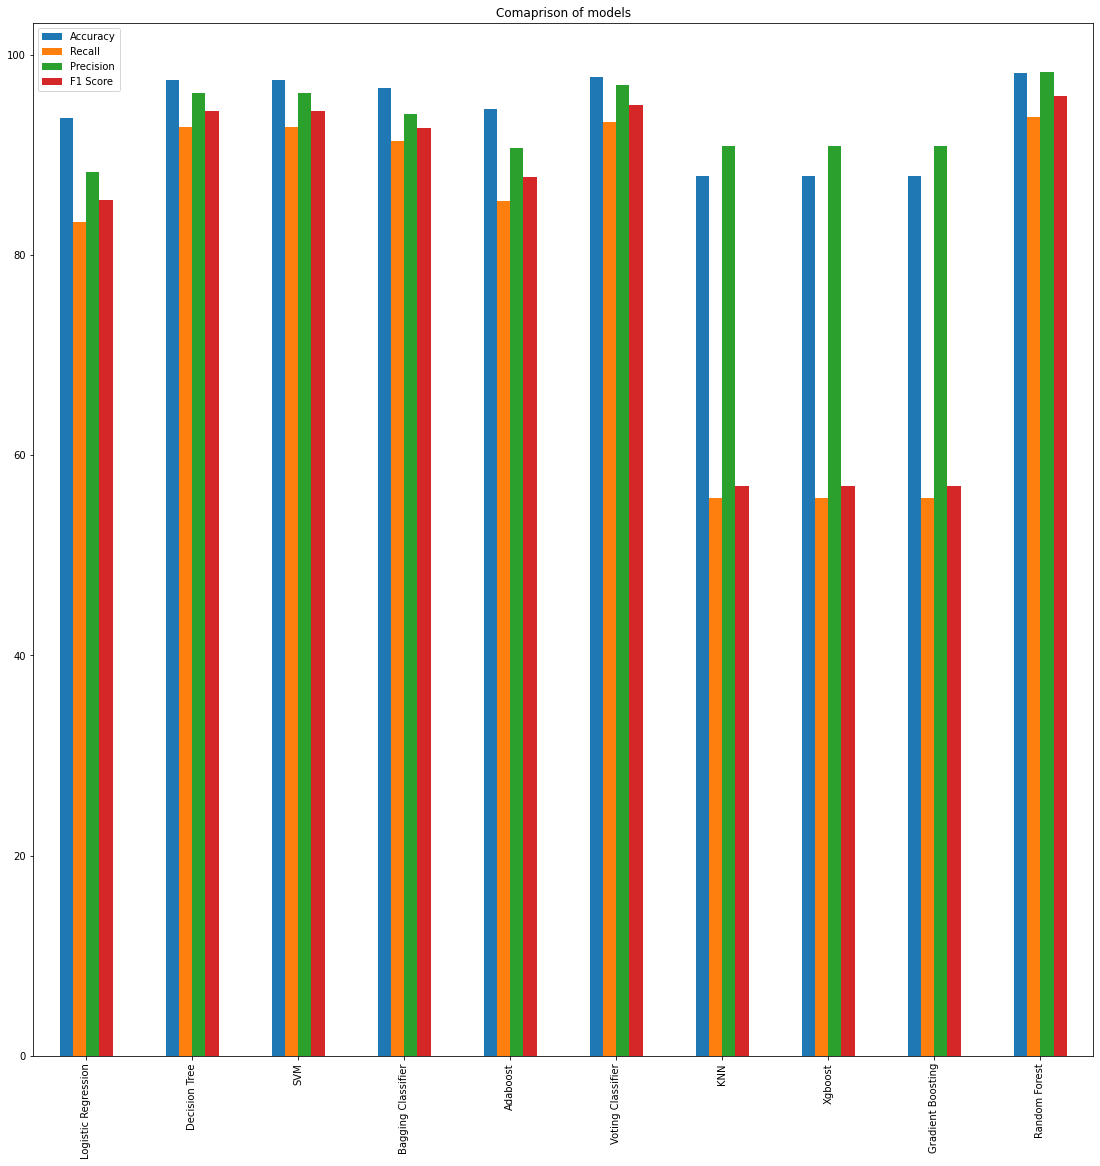

In [51]:
fig =results.plot(kind='bar',title='Comaprison of models',figsize =(19,19)).get_figure()
fig.savefig('Final Result.png')

array([<AxesSubplot:title={'center':'Accuracy'}>,
       <AxesSubplot:title={'center':'Recall'}>,
       <AxesSubplot:title={'center':'Precision'}>,
       <AxesSubplot:title={'center':'F1 Score'}>], dtype=object)

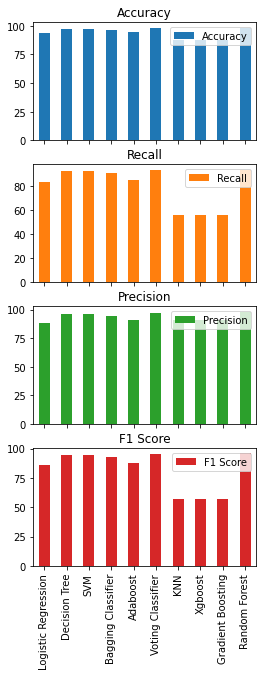

In [52]:
results.plot(subplots=True,kind ='bar',figsize=(4,10))

# Execution Time

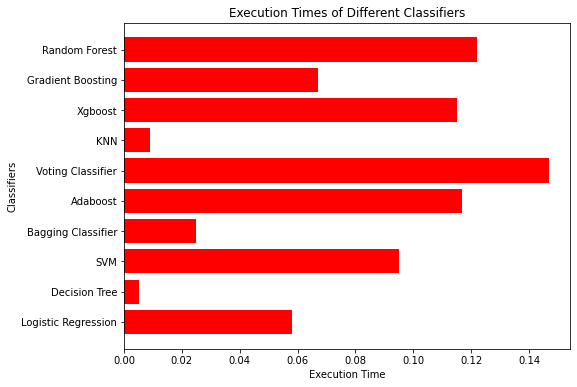

In [53]:
classifiers = ['Logistic Regression','Decision Tree','SVM','Bagging Classifier','Adaboost','Voting Classifier','KNN','Xgboost','Gradient Boosting','Random Forest']
execution_times = [lr_time, dt_time, svm_time, bg_time, ada_time, vt_time,knn_time,xg_time,gb_time,rf_time]
plt.figure(figsize=(8, 6))
plt.barh(classifiers, execution_times, color='red')
plt.xlabel('Execution Time')
plt.ylabel('Classifiers')
plt.title('Execution Times of Different Classifiers')
plt.show()

# Saving the model

In [54]:
pickle.dump(rf,open('model.sav','wb'))

# Saving the dataset

In [55]:
file_path = "data.xlsx"  


data.to_excel(file_path, index=False)